# Network variants for talk

Cleaned notebook to render the original PUD network with a cluster-influenced
ForceAtlas2 layout, alongside two densified variants.


In [32]:
!pip install graphistry

In [ ]:
from pathlib import Path
import sys
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx

from utils.network_plot_utils import draw_citation_graph

try:
    import colormaps
    COLORMAP = colormaps.redp1
except Exception:
    COLORMAP = plt.cm.viridis

plt.style.use("default")
sns.set_theme(style="white")
try:
    plt.style.use("opinionated_rc")
except OSError:
    pass

# Graphistry is required for cluster-influenced FA2 layouts
import graphistry
from networkx.algorithms.community import louvain_communities

# Make NetworkInequality utils importable
sys.path.append(str(Path("NetworkInequality").resolve()))
from network_utils import generate_network_variant

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## Load the base network


In [4]:
DATA_PATH = Path("NetworkInequality/empirical_networks/ego_network.pkl")

with DATA_PATH.open("rb") as f:
    pud_final = pickle.load(f)

print(f"Nodes: {pud_final.number_of_nodes():,}")
print(f"Edges: {pud_final.number_of_edges():,}")


Nodes: 503
Edges: 2,933


In [5]:
# # Save and load pud_final as JSON
# import json
# from networkx.readwrite import json_graph

# JSON_PATH = Path("NetworkInequality/empirical_networks/pud_final.json")

# # Save to JSON
# def save_network_json(G, path):
#     data = json_graph.node_link_data(G)
#     with open(path, "w") as f:
#         json.dump(data, f)
#     print(f"Saved network to {path}")

# # Load from JSON
# def load_network_json(path):
#     with open(path, "r") as f:
#         data = json.load(f)
#     G = json_graph.node_link_graph(data)
#     print(f"Loaded network from {path}")
#     return G

# # Example usage:
# # save_network_json(pud_final, JSON_PATH)
# pud_final = load_network_json(JSON_PATH)


## Optional: attach average publication year (pre-1978)

If the metadata file exists, it is loaded automatically. To recompute the
metadata with OpenAlex, set `RUN_OPENALEX = True` and ensure you have network
access plus the `pyalex` dependency.


In [6]:
META_PATH = Path("NetworkInequality/results_data_sets/pud_avg_pub_year_pre1978.csv")
RUN_OPENALEX = False

rebuild_metadata = True
df_avg = None
if META_PATH.exists() and not rebuild_metadata:
    df_avg = pd.read_csv(META_PATH)
elif RUN_OPENALEX:
    from pyalex import Works
    import pyalex
    from concurrent.futures import ThreadPoolExecutor, as_completed
    from collections import defaultdict
    import math
    from tqdm import tqdm

    pyalex.config.email = "you@example.com"

    raw_nodes = list(pud_final.nodes())
    author_ids = []
    for x in raw_nodes:
        s = str(x).strip()
        if s.startswith("https://openalex.org/"):
            s = s.rsplit("/", 1)[-1]
        if s and s[0].upper() == "A":
            author_ids.append(s.upper())

    author_set = set(author_ids)
    print(f"{len(author_ids)} authors")

    def chunks(lst, n=100):
        for i in range(0, len(lst), n):
            yield lst[i : i + n]

    def fetch_chunk(aids):
        id_str = "|".join(aids)
        pager = (
            Works()
            .filter(author={"id": id_str}, to_publication_date="1977-12-31")
            #.select(["id", "publication_year", "authorships"])
            .paginate(per_page=200)
        )
        out = []
        for page in pager:
            out.extend(page)
            
            
        #print(out)
        return out

    sum_years = defaultdict(int)
    count_works = defaultdict(int)
    coauthors = defaultdict(set)
    

    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {ex.submit(fetch_chunk, ch): ch for ch in chunks(author_ids, 100)}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Chunks"):
            for w in fut.result():
                y = w.get("publication_year")
                if not isinstance(y, int):
                    continue
                # Collect all author ids in this work that are in our set
                work_authors_in_set = []
                # Collect all author ids in this work (regardless of whether in our set)
                all_work_authors = []
                for au in (w.get("authorships") or []):
                    aid = (au.get("author") or {}).get("id")
                    if not aid:
                        continue
                    aid_short = aid.rsplit("/", 1)[-1]
                    all_work_authors.append(aid_short)
                    if aid_short in author_set:
                        work_authors_in_set.append(aid_short)
                
                # Update stats and coauthors for each author in the work
                for aid_short in work_authors_in_set:
                    sum_years[aid_short] += y
                    count_works[aid_short] += 1
                    # Add all authors from this work as coauthors (not just those in our set)
                    for other_aid in all_work_authors:
                        if other_aid != aid_short:
                            coauthors[aid_short].add(other_aid)

    rows = []
    for aid in author_ids:
        n = count_works.get(aid, 0)
        avg = (sum_years[aid] / n) if n else math.nan
        rows.append({
            "author_id": aid,
            "works_pre1978": n,
            "avg_pub_year_pre1978": avg,
            "coauthors": list(coauthors.get(aid, []))
        })

    df_avg = pd.DataFrame(rows).sort_values(
        ["works_pre1978", "avg_pub_year_pre1978"], ascending=[False, True]
    )
    df_avg.to_csv(META_PATH, index=False)
else:
    print("No avg_pub_year_pre1978 metadata found; nodes will render in a flat color.")

if df_avg is not None:
    for _, row in df_avg.iterrows():
        full_author_id = f"https://openalex.org/{row['author_id']}"
        if full_author_id in pud_final:
            pud_final.nodes[full_author_id]["avg_pub_year_pre1978"] = row[
                "avg_pub_year_pre1978"
            ]
            pud_final.nodes[full_author_id]["works_pre1978"] = row["works_pre1978"]
            pud_final.nodes[full_author_id]["coauthors"] = row["coauthors"] if isinstance(row["coauthors"], list) else eval(row["coauthors"]) if isinstance(row["coauthors"], str) else []


No avg_pub_year_pre1978 metadata found; nodes will render in a flat color.


In [7]:
pud_final.nodes(data=True)

NodeDataView({'https://openalex.org/A5002896092': {'n_works': 2}, 'https://openalex.org/A5091383938': {'n_works': 1}, 'https://openalex.org/A5101708402': {'n_works': 1}, 'https://openalex.org/A5018693253': {'n_works': 1}, 'https://openalex.org/A5040984419': {'n_works': 3}, 'https://openalex.org/A5058050425': {'n_works': 1}, 'https://openalex.org/A5049869681': {'n_works': 1}, 'https://openalex.org/A5076620163': {'n_works': 1}, 'https://openalex.org/A5038213161': {'n_works': 3}, 'https://openalex.org/A5019378435': {'n_works': 1}, 'https://openalex.org/A5036310646': {'n_works': 1}, 'https://openalex.org/A5080000592': {'n_works': 1}, 'https://openalex.org/A5049765612': {'n_works': 2}, 'https://openalex.org/A5001381023': {'n_works': 1}, 'https://openalex.org/A5073802250': {'n_works': 1}, 'https://openalex.org/A5081889212': {'n_works': 1}, 'https://openalex.org/A5085085199': {'n_works': 1}, 'https://openalex.org/A5013948777': {'n_works': 4}, 'https://openalex.org/A5026569660': {'n_works': 1}

In [8]:
# Check if A5113573464 is in the coauthor nodes
target_author = "https://openalex.org/A5113573464"
if target_author in pud_final.nodes:
    print(f"{target_author} is in the network")
    print(f"Node data: {pud_final.nodes[target_author]}")
else:
    print(f"{target_author} is NOT in the network")

# Also check without the full URL prefix
target_short = "A5113573464"
matching_nodes = [n for n in pud_final.nodes if target_short in pud_final.nodes[n]['coauthors']]
print(f"Nodes containing '{target_short}': {matching_nodes}")


https://openalex.org/A5113573464 is NOT in the network


KeyError: 'coauthors'

## Helpers


In [12]:
HAMMER_PARAMS = {
    "accuracy": 500,
    "advect_iterations": 50,
    "batch_size": 20000,
    "decay": 0.009,
    "initial_bandwidth": 1.2,
    "iterations": 6,
    "max_segment_length": 0.016,
    "min_segment_length": 0.008,
    "tension": 1.4,
}


def compute_cluster_layout(G, seed=SEED, niter=10000):
    comms = louvain_communities(G, seed=seed)
    cluster = {n: i for i, c in enumerate(comms) for n in c}
    nx.set_node_attributes(G, cluster, "cluster")

    g = graphistry.bind(source="src", destination="dst").from_networkx(G)
    g_layout = g.modularity_weighted_layout(
        community_col="cluster",
        cross_community_weight=0.1,
        same_community_weight=5,
    )
    g_layout = g_layout.layout_igraph('fr', directed=False, params={"weights": "weight", "niter": niter})
    position_df = pd.DataFrame(g_layout.__dict__["_nodes"]).set_index("n")
    return position_df


def plot_network_panel(
    ax,
    G,
    position_df,
    title,
    *,
    cmap=COLORMAP,
    norm=None,
    min_year=1925,
    show_colorbar=False,
    title_y=1.02,
):
    node_ids = list(G.nodes())
    xy = position_df.loc[node_ids, ["x", "y"]].to_numpy()
    degrees = np.array([G.degree(n) for n in node_ids])
    node_sizes = degrees * 10 + 1

    for node, (x, y) in zip(node_ids, xy):
        G.nodes[node]["X"] = x
        G.nodes[node]["Y"] = y
        G.nodes[node]["color"] = "#80808080"

    draw_citation_graph(G, ax=ax, bundle_edges=True, alpha=0.3, hammer_kwargs=HAMMER_PARAMS)

    color_values = np.array(
        [G.nodes[n].get("avg_pub_year_pre1978", np.nan) for n in node_ids], dtype=float
    )
    if np.isfinite(color_values).any():
        color_values = np.clip(color_values, min_year, None)
        ax.scatter(
            xy[:, 0],
            xy[:, 1],
            s=node_sizes,
            c=color_values,
            cmap=cmap,
            norm=norm,
            alpha=0.5,
            linewidth=0.5,
            zorder=2,
        )
        if show_colorbar and norm is not None:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            plt.colorbar(sm, ax=ax, shrink=0.6)
    else:
        ax.scatter(
            xy[:, 0],
            xy[:, 1],
            s=node_sizes,
            c="lightgray",
            alpha=0.5,
            linewidth=0.5,
            zorder=2,
        )

    ax.set_title(title, y=title_y)
    #ax.set_aspect("equal", adjustable="box")
    ax.axis("off")


## Build densified variants


In [14]:
G_original = pud_final.copy()

In [15]:
int(len(G_original.edges)/3)


977

In [16]:
p = 0.5
DENSIFY_CONFIGS = [
    (
        "b) Equalized",
        {
            "n_edges": int(len(G_original.edges)*0.5),
            "target_degree_dist": "uniform",
            "target_average_clustering": None,
            "keep_density_fixed": True,
        },
    ),
    (
        "c) Densified",
        {
            "n_edges": int(len(G_original.edges) * 0.5 ),
            "target_degree_dist": "original",
            "target_average_clustering": None,
            "keep_density_fixed": False,
        },
    ),
]

G_original = pud_final.copy()
G_variants = []

for label, params in DENSIFY_CONFIGS:
    G_variant = generate_network_variant(G_original, **params)
    G_variants.append((label, G_variant))


## Compute layouts


In [17]:
layout_original = compute_cluster_layout(G_original)
layouts_variants = [(label, compute_cluster_layout(G)) for label, G in G_variants]

color_values = np.array(
    [G_original.nodes[n].get("avg_pub_year_pre1978", np.nan) for n in G_original.nodes()],
    dtype=float,
)
MIN_YEAR = 1925
if np.isfinite(color_values).any():
    color_values = np.clip(color_values, MIN_YEAR, None)
    vmax = np.nanmax(color_values)
    COLOR_NORM = plt.Normalize(vmin=MIN_YEAR, vmax=vmax)
else:
    COLOR_NORM = None


edge index g._edge not set so using edge index as ID; set g._edge via g.edges(), or change merge_if_existing to False
edge index g._edge __edge_index__ missing as attribute in ig; using ig edge order for IDs
edge index g._edge not set so using edge index as ID; set g._edge via g.edges(), or change merge_if_existing to False
edge index g._edge __edge_index__ missing as attribute in ig; using ig edge order for IDs
edge index g._edge not set so using edge index as ID; set g._edge via g.edges(), or change merge_if_existing to False
edge index g._edge __edge_index__ missing as attribute in ig; using ig edge order for IDs


## Facet plot


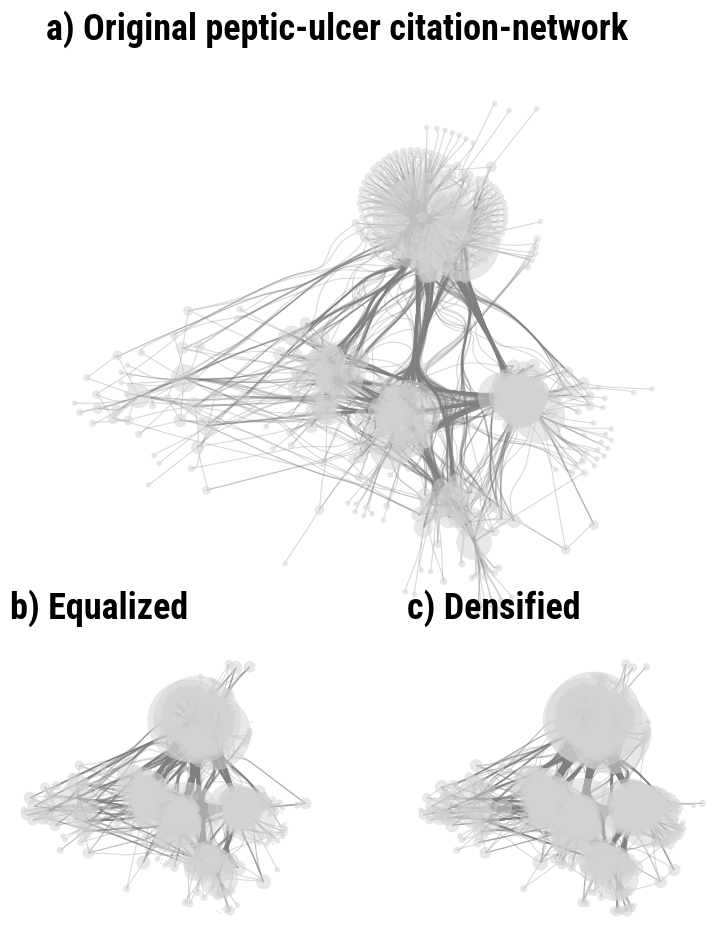

In [18]:
fig = plt.figure(figsize=(10, 11))

gs = fig.add_gridspec(3, 2, width_ratios=[1, 1], height_ratios=[1, 1, 1], wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[0:2, :])
ax_left = fig.add_subplot(gs[2, 0])
ax_right = fig.add_subplot(gs[2, 1])

plot_network_panel(
    ax_main,
    G_original,
    layout_original,
    "a) Original peptic-ulcer citation-network",
    norm=COLOR_NORM,
    show_colorbar=True,
)


plot_network_panel(
    ax_left,
    G_variants[0][1],
    layout_original,
    G_variants[0][0],
    norm=COLOR_NORM,
)

plot_network_panel(
    ax_right,
    G_variants[1][1],
    layout_original,
    G_variants[1][0],
    norm=COLOR_NORM,
)

# fig.su
# ptitle("PUD network variants", y=0.98)


plt.savefig("NetworkInequality/Figures/pud_network_variants.pdf", dpi=300, bbox_inches='tight')

plt.show()

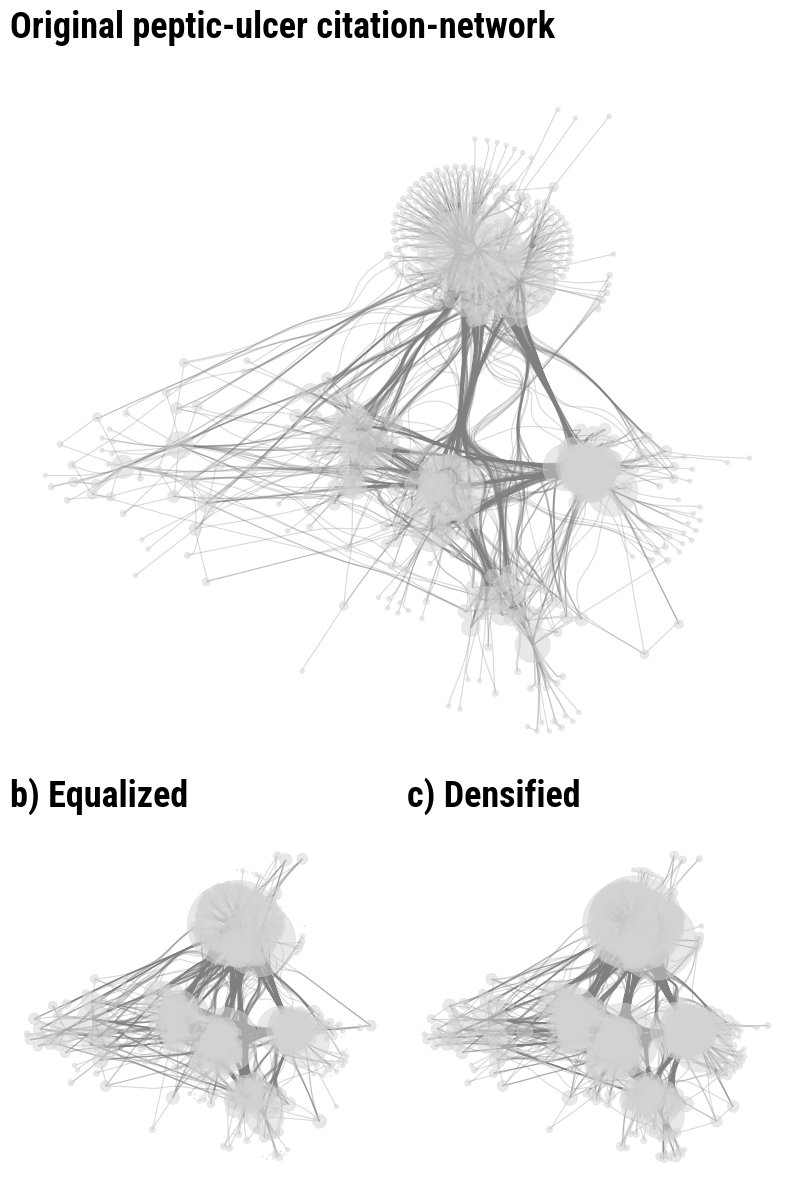

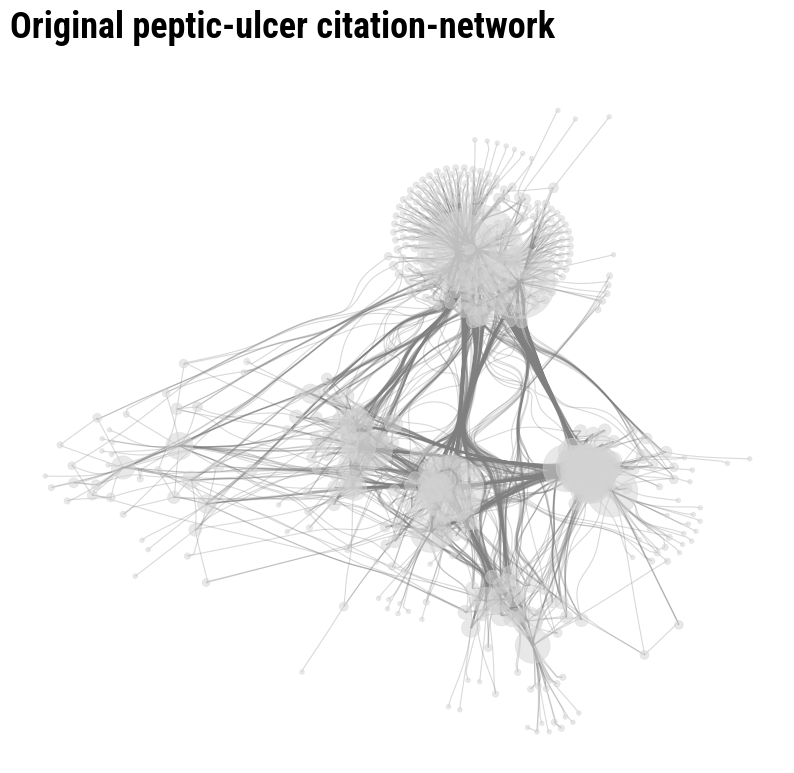

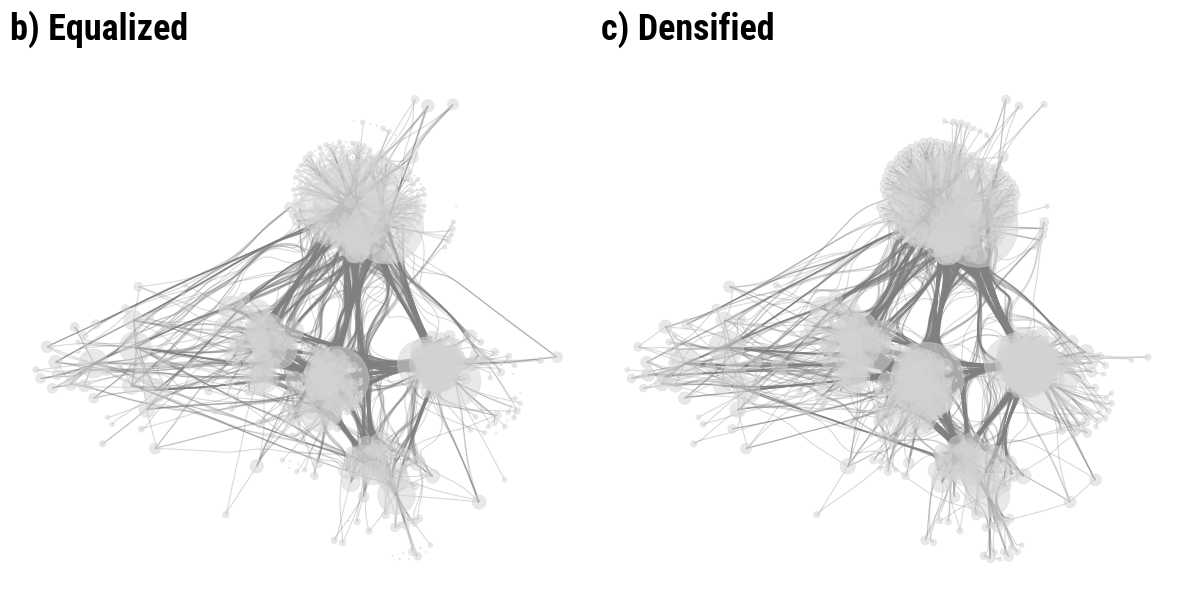

In [19]:
fig = plt.figure(figsize=(10, 15))

gs = fig.add_gridspec(3, 2, width_ratios=[1, 1], height_ratios=[1, 1, 1], wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[0:2, :])
ax_left = fig.add_subplot(gs[2, 0])
ax_right = fig.add_subplot(gs[2, 1])

plot_network_panel(
    ax_main,
    G_original,
    layout_original,
    "Original peptic-ulcer citation-network",
    norm=COLOR_NORM,
    show_colorbar=True,
)

plot_network_panel(
    ax_left,
    G_variants[0][1],
    layout_original,
    G_variants[0][0],
    norm=COLOR_NORM,
)

plot_network_panel(
    ax_right,
    G_variants[1][1],
    layout_original,
    G_variants[1][0],
    norm=COLOR_NORM,
)

# fig.su
# ptitle("PUD network variants", y=0.98)


plt.savefig("NetworkInequality/Figures/pud_network_variants.pdf", dpi=300)

plt.show()

# Create separate plot for original network only
fig_original, ax_original = plt.subplots(figsize=(10, 10))
plot_network_panel(
    ax_original,
    G_original,
    layout_original,
    "Original peptic-ulcer citation-network",
    norm=COLOR_NORM,
    show_colorbar=True,
)
plt.savefig("NetworkInequality/Figures/pud_network_original.pdf", dpi=300)
plt.show()

# Create separate plot for variant networks
fig_variants, (ax_v1, ax_v2) = plt.subplots(1, 2, figsize=(12, 6))
plot_network_panel(
    ax_v1,
    G_variants[0][1],
    layout_original,
    G_variants[0][0],
    norm=COLOR_NORM,
)
plot_network_panel(
    ax_v2,
    G_variants[1][1],
    layout_original,
    G_variants[1][0],
    norm=COLOR_NORM,
)
plt.tight_layout()
plt.savefig("NetworkInequality/Figures/pud_network_changed.pdf", dpi=300)
plt.show()

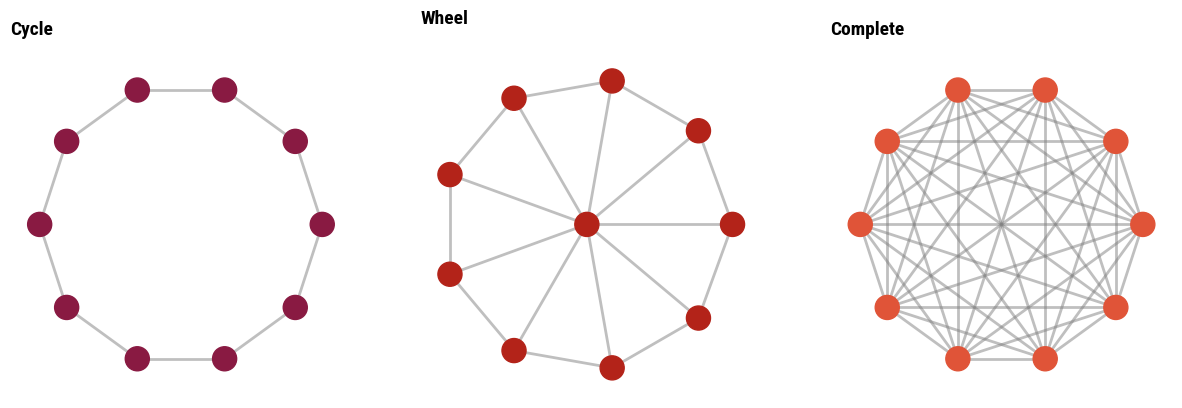

In [20]:
# Replicate Figure 2: 10 person cycle, wheel, and complete graph
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))

# Create the three networks
n = 10

# Cycle graph
G_cycle = nx.cycle_graph(n)
pos_cycle = nx.circular_layout(G_cycle)

# Wheel graph
G_wheel = nx.wheel_graph(n)
# Create circular layout for outer nodes (1 through n)
outer_nodes = list(range(1, n + 1))
pos_wheel = nx.circular_layout(G_wheel.subgraph(outer_nodes))
# Set center node (0) at origin
pos_wheel[0] = np.array([0.0, 0.0])


# Complete graph
G_complete = nx.complete_graph(n)
pos_complete = nx.circular_layout(G_complete)

# Generate random values for nodes
np.random.seed(42)  # For reproducibility
values_cycle = np.full(n, 0.3)
values_wheel = np.full(n, 0.5)
values_complete = np.full(n, 0.7)

# Plot cycle
nx.draw_networkx_nodes(G_cycle, pos_cycle, ax=axes[0], node_color=values_cycle, node_size=300, cmap=COLORMAP, vmin=0, vmax=1)
nx.draw_networkx_edges(G_cycle, pos_cycle, ax=axes[0], edge_color='gray', width=2, alpha=0.5)
# Add invisible scatterplot for all nodes
x_cycle = [pos_cycle[node][0] for node in G_cycle.nodes()]
y_cycle = [pos_cycle[node][1] for node in G_cycle.nodes()]
axes[0].scatter(x_cycle, y_cycle, s=300, alpha=0)
axes[0].set_title("Cycle", fontsize=14)
axes[0].axis('off')
axes[0].set_aspect('equal')

# Plot wheel
nx.draw_networkx_nodes(G_wheel, pos_wheel, ax=axes[1], node_color=values_wheel, node_size=300, cmap=COLORMAP, vmin=0, vmax=1)
nx.draw_networkx_edges(G_wheel, pos_wheel, ax=axes[1], edge_color='gray', width=2, alpha=0.5)
# Add invisible scatterplot for all nodes
x_wheel = [pos_wheel[node][0] for node in G_wheel.nodes()]
y_wheel = [pos_wheel[node][1] for node in G_wheel.nodes()]
axes[1].scatter(x_wheel, y_wheel, s=300, alpha=0)
axes[1].set_title("Wheel", fontsize=14)
axes[1].axis('off')
axes[1].set_aspect('equal')

# Plot complete
nx.draw_networkx_nodes(G_complete, pos_complete, ax=axes[2], node_color=values_complete, node_size=300, cmap=COLORMAP, vmin=0, vmax=1)
nx.draw_networkx_edges(G_complete, pos_complete, ax=axes[2], edge_color='gray', width=2, alpha=0.5)
# Add invisible scatterplot for all nodes
x_complete = [pos_complete[node][0] for node in G_complete.nodes()]
y_complete = [pos_complete[node][1] for node in G_complete.nodes()]
axes[2].scatter(x_complete, y_complete, s=300, alpha=0)
axes[2].set_title("Complete", fontsize=14)
axes[2].axis('off')
axes[2].set_aspect('equal')

#plt.tight_layout()
plt.savefig("NetworkInequality/Figures/basic_network_types.pdf", dpi=300)
plt.show()


In [21]:
pos_wheel

{1: array([1.00000000e+00, 1.98682148e-08]),
 2: array([0.76604444, 0.64278759]),
 3: array([0.17364823, 0.98480774]),
 4: array([-0.50000005,  0.8660254 ]),
 5: array([-0.9396926 ,  0.34202023]),
 6: array([-0.9396926 , -0.34202013]),
 7: array([-0.4999999 , -0.86602542]),
 8: array([ 0.17364817, -0.9848077 ]),
 9: array([ 0.76604432, -0.64278773]),
 0: array([0., 0.])}

In [22]:
make all of these only consider outdegrees, and include zerodegrees


SyntaxError: invalid syntax (4141085154.py, line 1)

Degree Distribution Analysis

Original:
  Nodes: 503, Edges: 2933
  Gini coefficient: 0.9204


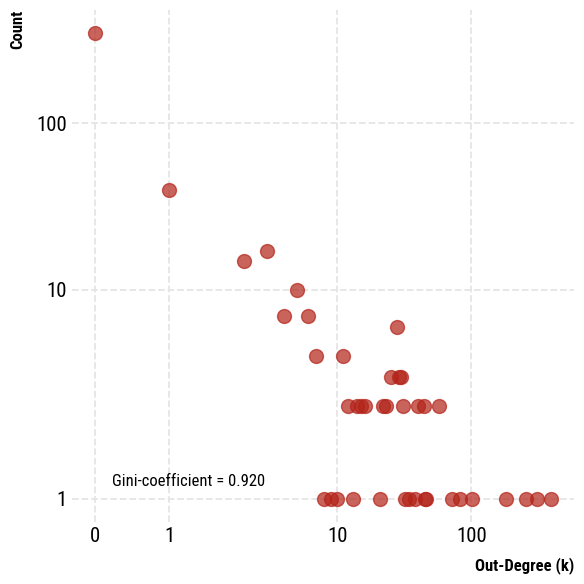

In [23]:
import numpy as np
from matplotlib.ticker import ScalarFormatter

# Calculate degree distributions for original network only
networks = [
    ("Original", G_original),
]

def gini_coefficient(x):
    """Calculate Gini coefficient of a distribution."""
    x = np.array(x, dtype=float)
    # Keep zeros for Gini calculation
    if len(x) == 0:
        return 0
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    if cumx[-1] == 0:
        return 0
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n


def calculate_degree_gini(G, directed=True):
    """OURS"""
    if directed:
        degrees = [deg for _, deg in G.out_degree()]
    else:
        degrees = [deg for _, deg in G.degree()]
    # Sort the degrees in ascending order
    sorted_x = np.sort(np.array(degrees))
    n = len(np.array(degrees))
    cumx = np.cumsum(sorted_x, dtype=float)
    if cumx[-1] == 0:
        return 0
    gini = (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

    return gini



print("=" * 60)
print("Degree Distribution Analysis")
print("=" * 60)

degree_data = {}

for name, G in networks:
    
    # Use out-degree and include all nodes (including 0 degree)
    degrees = [d for n, d in G.out_degree()]
    
    degree_data[name] = degrees
    
    # Gini coefficient
    gini = calculate_degree_gini(G, directed=True)
    
    print(f"\n{name}:")
    print(f"  Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
    print(f"  Gini coefficient: {gini:.4f}")

# Plot symlog degree distributions
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# Get color from COLORMAP at 0.5
point_color = COLORMAP(0.5)

for idx, (name, G) in enumerate(networks):
    ax = axes
    degrees = degree_data[name]
    
    # Calculate degree distribution (including zeros)
    unique_degrees, counts = np.unique(degrees, return_counts=True)
    
    # Plot empirical distribution with larger points (using counts instead of probabilities)
    ax.plot(unique_degrees, counts, 'o', color=point_color, alpha=0.7, label='Empirical', markersize=10)
    
    ax.set_xscale('symlog')
    ax.set_yscale('symlog')
    ax.set_xlabel('Out-Degree (k)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
   # ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Format axes to show real numbers instead of scientific notation
    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(ScalarFormatter())
        axis.set_minor_formatter(ScalarFormatter())
    
    ax.yaxis.set_minor_locator(plt.NullLocator())
    ax.yaxis.set_minor_formatter(plt.NullFormatter())
    ax.grid(True, alpha=1.)
    
    # Add Gini annotation towards the right side center of the plot
    ax.text(0.08, 0.08, f'Gini-coefficient = {gini_coefficient(degrees):.3f}', 
            transform=ax.transAxes, fontsize=12, verticalalignment='center')

plt.tight_layout()
plt.savefig("NetworkInequality/Figures/degree_distributions_loglog.pdf", dpi=300)
plt.show()


Degree Distribution Analysis with Power Law Statistics

Original:
  Nodes: 503, Edges: 2933
  Gini coefficient: 0.9204
  Power Law Fit:7%
    Alpha (exponent): 2.2843 ± 0.2872
    xmin: 31.0
  Comparison Tests (positive R favors power law):
    Power law vs Exponential: R = 2.0477, p = 0.0406
    Power law vs Lognormal: R = -0.0211, p = 0.9831


Assuming nested distributions


    Power law vs Truncated Power Law: R = -0.3995, p = 0.6730
    Lognormal vs Exponential: R = 2.0497, p = 0.0404
    Lognormal vs Truncated Power Law: R = -0.4028, p = 0.6871
  Lognormal Fit:
    mu: -617.3632
    sigma: 22.0113

Equalized:
  Nodes: 503, Edges: 2933
  Gini coefficient: 0.8333
  Power Law Fit:7%
    Alpha (exponent): 2.2961 ± 0.2646
    xmin: 23.0
  Comparison Tests (positive R favors power law):
    Power law vs Exponential: R = 1.6504, p = 0.0989
    Power law vs Lognormal: R = -0.2844, p = 0.7761


Assuming nested distributions


    Power law vs Truncated Power Law: R = -0.6187, p = 0.5029
    Lognormal vs Exponential: R = 1.8447, p = 0.0651
    Lognormal vs Truncated Power Law: R = -0.9510, p = 0.3416
  Lognormal Fit:
    mu: -3.8743
    sigma: 2.5498

Densified:
  Nodes: 503, Edges: 4399
  Gini coefficient: 0.8946
  Power Law Fit:8%
    Alpha (exponent): 1.4030 ± 0.0281
    xmin: 1.0
  Comparison Tests (positive R favors power law):
    Power law vs Exponential: R = 3.2094, p = 0.0013
    Power law vs Lognormal: R = -4.5893, p = 0.0000


Assuming nested distributions


    Power law vs Truncated Power Law: R = -4.9986, p = 0.0000
    Lognormal vs Exponential: R = 4.7208, p = 0.0000
    Lognormal vs Truncated Power Law: R = -1.0157, p = 0.3098
  Lognormal Fit:
    mu: 1.0098
    sigma: 2.0741


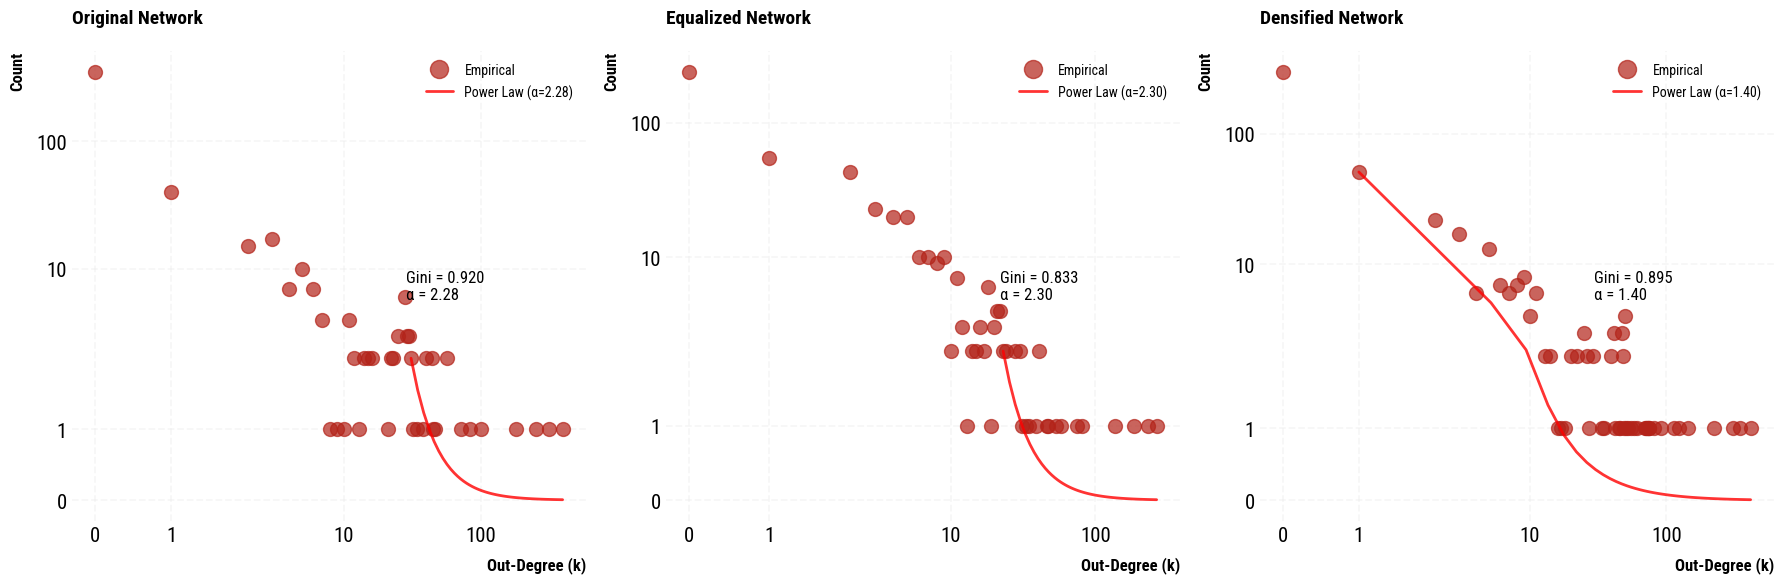

In [24]:
import powerlaw
import numpy as np
from matplotlib.ticker import ScalarFormatter

# Calculate degree distributions for all three networks
networks = [
    ("Original", G_original),
    ("Equalized", G_variants[0][1]),
    ("Densified", G_variants[1][1]),
]

def gini_coefficient(x):
    """Calculate Gini coefficient of a distribution."""
    x = np.array(x, dtype=float)
    if len(x) == 0:
        return 0
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    if cumx[-1] == 0:
        return 0
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n


def calculate_degree_gini(G, directed=True):
    """Calculate Gini coefficient for degree distribution."""
    if directed:
        degrees = [deg for _, deg in G.out_degree()]
    else:
        degrees = [deg for _, deg in G.degree()]
    sorted_x = np.sort(np.array(degrees))
    n = len(np.array(degrees))
    cumx = np.cumsum(sorted_x, dtype=float)
    if cumx[-1] == 0:
        return 0
    gini = (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n
    return gini


print("=" * 60)
print("Degree Distribution Analysis with Power Law Statistics")
print("=" * 60)

degree_data = {}
powerlaw_results = {}

for name, G in networks:
    # Use out-degree and include all nodes (including 0 degree)
    degrees = [d for n, d in G.out_degree()]
    degree_data[name] = degrees
    
    # Gini coefficient
    gini = calculate_degree_gini(G, directed=True)
    
    # Power law analysis (filter out zeros for powerlaw package)
    degrees_nonzero = [d for d in degrees if d > 0]
    
    print(f"\n{name}:")
    print(f"  Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
    print(f"  Gini coefficient: {gini:.4f}")
    
    if len(degrees_nonzero) > 0:
        # Fit power law
        fit = powerlaw.Fit(degrees_nonzero, discrete=True, verbose=False)
        
        # Store results
        powerlaw_results[name] = {
            'fit': fit,
            'alpha': fit.power_law.alpha,
            'xmin': fit.power_law.xmin,
            'sigma': fit.power_law.sigma,
        }
        
        print(f"  Power Law Fit:")
        print(f"    Alpha (exponent): {fit.power_law.alpha:.4f} ± {fit.power_law.sigma:.4f}")
        print(f"    xmin: {fit.power_law.xmin}")
        
        # Compare power law to alternatives
        # Power law vs exponential
        R_exp, p_exp = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)
        print(f"  Comparison Tests (positive R favors power law):")
        print(f"    Power law vs Exponential: R = {R_exp:.4f}, p = {p_exp:.4f}")
        
        # Power law vs lognormal
        R_ln, p_ln = fit.distribution_compare('power_law', 'lognormal', normalized_ratio=True)
        print(f"    Power law vs Lognormal: R = {R_ln:.4f}, p = {p_ln:.4f}")
        
        # Power law vs truncated power law
        R_tpl, p_tpl = fit.distribution_compare('power_law', 'truncated_power_law', normalized_ratio=True)
        print(f"    Power law vs Truncated Power Law: R = {R_tpl:.4f}, p = {p_tpl:.4f}")
        
        # Lognormal vs exponential (to test if lognormal is preferred)
        R_ln_exp, p_ln_exp = fit.distribution_compare('lognormal', 'exponential', normalized_ratio=True)
        print(f"    Lognormal vs Exponential: R = {R_ln_exp:.4f}, p = {p_ln_exp:.4f}")
        
        # Lognormal vs truncated power law
        R_ln_tpl, p_ln_tpl = fit.distribution_compare('lognormal', 'truncated_power_law', normalized_ratio=True)
        print(f"    Lognormal vs Truncated Power Law: R = {R_ln_tpl:.4f}, p = {p_ln_tpl:.4f}")
        
        # Print lognormal fit parameters
        if fit.lognormal is not None:
            print(f"  Lognormal Fit:")
            print(f"    mu: {fit.lognormal.mu:.4f}")
            print(f"    sigma: {fit.lognormal.sigma:.4f}")
        
        powerlaw_results[name]['comparisons'] = {
            'exponential': (R_exp, p_exp),
            'lognormal': (R_ln, p_ln),
            'truncated_power_law': (R_tpl, p_tpl),
            'lognormal_vs_exponential': (R_ln_exp, p_ln_exp),
            'lognormal_vs_truncated_power_law': (R_ln_tpl, p_ln_tpl),
        }

# Plot degree distributions for all three networks
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Get color from COLORMAP at 0.5
point_color = COLORMAP(0.5)
powerlaw_color = 'red'

for idx, (name, G) in enumerate(networks):
    ax = axes[idx]
    degrees = degree_data[name]
    
    # Calculate degree distribution (including zeros) - using counts
    unique_degrees, counts = np.unique(degrees, return_counts=True)
    
    # Plot empirical distribution with larger points (using counts)
    ax.plot(unique_degrees, counts, 'o', color=point_color, alpha=0.7, label='Empirical', markersize=10)
    
    # Plot fitted power law line if available
    if name in powerlaw_results:
        fit = powerlaw_results[name]['fit']
        alpha = powerlaw_results[name]['alpha']
        xmin = powerlaw_results[name]['xmin']
        
        # Generate x values for the power law line (from xmin to max degree)
        x_powerlaw = np.linspace(xmin, max(degrees), 100)
        
        # Calculate the normalization constant C such that the line matches at xmin
        # Find the empirical count at or near xmin for scaling
        degrees_above_xmin = unique_degrees[unique_degrees >= xmin]
        counts_above_xmin = counts[unique_degrees >= xmin]
        
        if len(degrees_above_xmin) > 0:
            # Use the first point at or above xmin for normalization
            C = counts_above_xmin[0] * (degrees_above_xmin[0] ** alpha)
            y_powerlaw = C * (x_powerlaw ** (-alpha))
            
            ax.plot(x_powerlaw, y_powerlaw, '-', color=powerlaw_color, linewidth=2, 
                    label=f'Power Law (α={alpha:.2f})', alpha=0.8)
    
    ax.set_xscale('symlog')
    ax.set_yscale('symlog')
    ax.set_xlabel('Out-Degree (k)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'{name} Network', fontsize=14)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Format axes to show real numbers instead of scientific notation
    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(ScalarFormatter())
        axis.set_minor_formatter(ScalarFormatter())
    
    ax.yaxis.set_minor_locator(plt.NullLocator())
    ax.yaxis.set_minor_formatter(plt.NullFormatter())
    
    # Add Gini and power law annotations
    gini = gini_coefficient(degrees)
    annotation_text = f'Gini = {gini:.3f}'
    if name in powerlaw_results:
        alpha = powerlaw_results[name]['alpha']
        annotation_text += f'\nα = {alpha:.2f}'
    
    ax.text(0.65, 0.5, annotation_text, 
            transform=ax.transAxes, fontsize=12, verticalalignment='center')

plt.tight_layout()
plt.savefig("NetworkInequality/Figures/degree_distributions_all_networks_loglog.pdf", dpi=300)
plt.show()


In [27]:
# Print nodes with highest out degree for each network
for name, G in [("PUD", G_original)]:
    out_degrees = dict(G.out_degree())
    sorted_nodes = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)
    print(f"\n{name} Network - Top 10 nodes by out-degree:")
    for node, degree in sorted_nodes[:10]:
        print(f"  {node}: {degree}")


PUD Network - Top 10 nodes by out-degree:
  https://openalex.org/A5083945877: 394
  https://openalex.org/A5025096563: 311
  https://openalex.org/A5007916326: 254
  https://openalex.org/A5005082745: 181
  https://openalex.org/A5012701585: 101
  https://openalex.org/A5053479856: 83
  https://openalex.org/A5040768864: 72
  https://openalex.org/A5057291202: 57
  https://openalex.org/A5001390698: 57
  https://openalex.org/A5052480262: 46
